In [2]:
import pandas as pd
from google.colab import files

uploaded = files.upload()  # upload train.csv when prompted
df_train = pd.read_csv('train.csv')
print(df_train.head(18))
print("\nColumns:", df_train.columns.tolist())
print("\nTool condition counts:")
print(df_train['tool_condition'].value_counts())


Saving train.csv to train.csv
    No material  feedrate  clamp_pressure tool_condition machining_finalized  \
0    1      wax         6             4.0         unworn                 yes   
1    2      wax        20             4.0         unworn                 yes   
2    3      wax         6             3.0         unworn                 yes   
3    4      wax         6             2.5         unworn                  no   
4    5      wax        20             3.0         unworn                  no   
5    6      wax         6             4.0           worn                 yes   
6    7      wax        20             4.0           worn                  no   
7    8      wax        20             4.0           worn                 yes   
8    9      wax        15             4.0           worn                 yes   
9   10      wax        12             4.0           worn                 yes   
10  11      wax         3             4.0         unworn                 yes   
11  12    

In [3]:
uploaded2 = files.upload()  # upload experiment_01.csv

df_exp = pd.read_csv('experiment_01.csv')
print(df_exp.shape)          # how many rows x columns?
print(df_exp.head())
print(df_exp['Machining_Process'].unique())  # what stages exist?

Saving experiment_01.csv to experiment_01.csv
(1055, 48)
   X1_ActualPosition  X1_ActualVelocity  X1_ActualAcceleration  \
0              198.0                0.0                   0.00   
1              198.0              -10.8                -350.00   
2              196.0              -17.8                  -6.25   
3              194.0              -18.0                   0.00   
4              193.0              -17.9                 -18.80   

   X1_CommandPosition  X1_CommandVelocity  X1_CommandAcceleration  \
0               198.0                 0.0                0.000000   
1               198.0               -13.6             -358.000000   
2               196.0               -17.9               -0.000095   
3               194.0               -17.9               -0.000095   
4               192.0               -17.9                0.000095   

   X1_CurrentFeedback  X1_DCBusVoltage  X1_OutputCurrent  X1_OutputVoltage  \
0                0.18           0.0207             32

In [4]:
import pandas as pd
import numpy as np
from google.colab import files

# Step 1: Upload ALL 18 experiment files at once
uploaded = files.upload()  # select all 18 files together

# Step 2: Load train labels
df_train = pd.read_csv('train.csv')

# Step 3: Active cutting stages only (ignore Prep/Repositioning)
active_stages = ['Layer 1 Up', 'Layer 1 Down',
                 'Layer 2 Up', 'Layer 2 Down',
                 'Layer 3 Up', 'Layer 3 Down']

# Step 4: Sensor columns to extract features from
sensor_cols = [
    'X1_ActualVelocity', 'X1_ActualAcceleration', 'X1_OutputCurrent',
    'Y1_ActualVelocity', 'Y1_ActualAcceleration', 'Y1_OutputCurrent',
    'Z1_ActualVelocity', 'Z1_ActualAcceleration', 'Z1_OutputCurrent',
    'S1_ActualVelocity', 'S1_OutputCurrent', 'S1_SystemInertia'
]

# Step 5: Extract features from each experiment
all_features = []

for i in range(1, 19):
    filename = f'experiment_{i:02d}.csv'
    df = pd.read_csv(filename)

    # Filter active machining only
    df_active = df[df['Machining_Process'].isin(active_stages)]

    row = {'experiment': i}

    # For each sensor, extract 4 statistical features
    for col in sensor_cols:
        if col in df_active.columns:
            row[f'{col}_mean'] = df_active[col].mean()
            row[f'{col}_std']  = df_active[col].std()
            row[f'{col}_max']  = df_active[col].max()
            row[f'{col}_rms']  = np.sqrt(np.mean(df_active[col]**2))

    all_features.append(row)
    print(f"✅ Processed experiment_{i:02d}")

# Step 6: Make feature dataframe
df_features = pd.DataFrame(all_features)

# Step 7: Merge with labels
df_train['experiment'] = df_train['No']
df_final = df_features.merge(df_train[['experiment', 'tool_condition']],
                              on='experiment')

print("\n✅ Final dataset shape:", df_final.shape)
print(df_final['tool_condition'].value_counts())
df_final.head()

Saving experiment_01.csv to experiment_01 (1).csv
Saving experiment_02.csv to experiment_02.csv
Saving experiment_03.csv to experiment_03.csv
Saving experiment_04.csv to experiment_04.csv
Saving experiment_05.csv to experiment_05.csv
Saving experiment_06.csv to experiment_06.csv
Saving experiment_07.csv to experiment_07.csv
Saving experiment_08.csv to experiment_08.csv
Saving experiment_09.csv to experiment_09.csv
Saving experiment_10.csv to experiment_10.csv
Saving experiment_11.csv to experiment_11.csv
Saving experiment_12.csv to experiment_12.csv
Saving experiment_13.csv to experiment_13.csv
Saving experiment_14.csv to experiment_14.csv
Saving experiment_15.csv to experiment_15.csv
Saving experiment_16.csv to experiment_16.csv
Saving experiment_17.csv to experiment_17.csv
Saving experiment_18.csv to experiment_18.csv
✅ Processed experiment_01
✅ Processed experiment_02
✅ Processed experiment_03
✅ Processed experiment_04
✅ Processed experiment_05
✅ Processed experiment_06
✅ Processed 

,experiment,X1_ActualVelocity_mean,X1_ActualVelocity_std,X1_ActualVelocity_max,X1_ActualVelocity_rms,X1_ActualAcceleration_mean,X1_ActualAcceleration_std,X1_ActualAcceleration_max,X1_ActualAcceleration_rms,X1_OutputCurrent_mean,...,S1_ActualVelocity_rms,S1_OutputCurrent_mean,S1_OutputCurrent_std,S1_OutputCurrent_max,S1_OutputCurrent_rms,S1_SystemInertia_mean,S1_SystemInertia_std,S1_SystemInertia_max,S1_SystemInertia_rms,tool_condition
0,1,-0.274712,4.504089,6.82,4.510190,3.321948,94.570589,1030.0,94.581218,325.831483,...,53.266744,319.984864,2.276088,324.0,319.992951,12.0,0.0,12.0,12.0,unworn
1,2,-0.335833,7.119508,20.20,7.124098,3.412629,132.149189,1440.0,132.131442,326.751169,...,26.091151,326.399439,5.099427,332.0,326.439234,12.0,0.0,12.0,12.0,unworn
2,3,-0.367994,4.677116,44.80,4.689395,-1.470289,95.474042,1060.0,95.440826,327.128731,...,44.358597,322.621269,4.747424,330.0,322.656164,12.0,0.0,12.0,12.0,unworn
3,4,0.904703,8.515011,50.70,8.551990,1.023256,66.500950,1020.0,66.422858,327.795866,...,29.856742,325.028424,5.732529,329.0,325.078842,12.0,0.0,12.0,12.0,unworn
4,5,-0.679028,8.554529,20.30,8.522010,34.144444,225.998549,944.0,227.006184,325.638889,...,34.577731,323.500000,4.975999,328.0,323.537736,12.0,0.0,12.0,12.0,unworn


✅ Model Accuracy: 33.3%

Detailed Report:
              precision    recall  f1-score   support

      unworn       0.17      0.12      0.14         8
        worn       0.42      0.50      0.45        10

    accuracy                           0.33        18
   macro avg       0.29      0.31      0.30        18
weighted avg       0.31      0.33      0.32        18



/tmp/ipykernel_7506/1227101890.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top15.values, y=top15.index, palette='viridis')


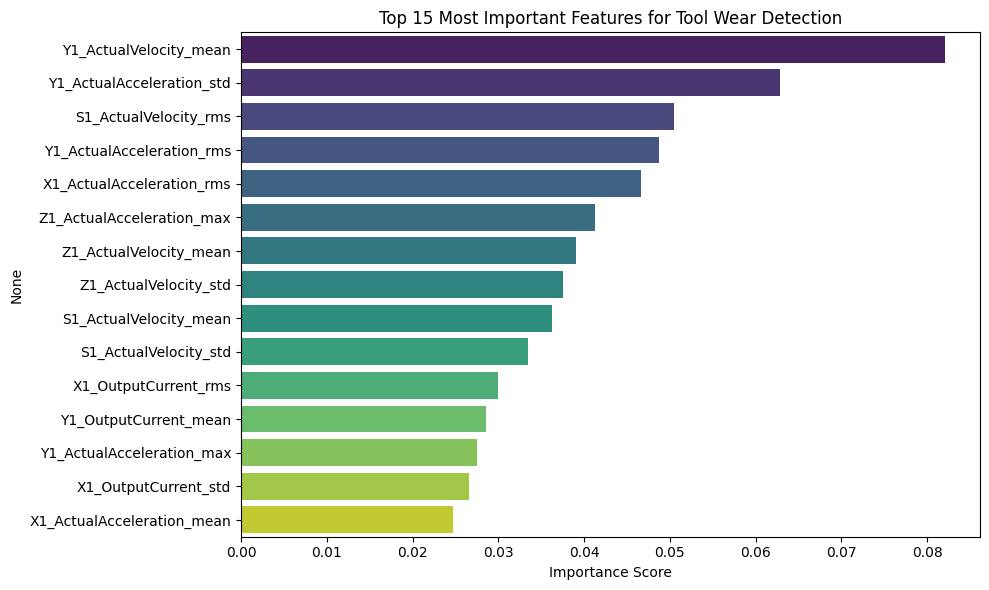

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Prepare X and y
X = df_final.drop(columns=['experiment', 'tool_condition'])
y = df_final['tool_condition']

# Encode label: worn=1, unworn=0
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Step 2: Handle any missing values
X = X.fillna(X.mean())

# Step 3: Train using Leave-One-Out Cross Validation
# (We use LOO because we only have 18 samples — standard train/test split won't work well)
loo = LeaveOneOut()
y_true, y_pred = [], []

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred.append(model.predict(X_test)[0])
    y_true.append(y_test[0])

# Step 4: Results
accuracy = accuracy_score(y_true, y_pred)
print(f"✅ Model Accuracy: {accuracy*100:.1f}%")
print("\nDetailed Report:")
print(classification_report(y_true, y_pred,
      target_names=le.classes_))

# Step 5: Train final model on ALL data (for saving)
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X, y_encoded)

# Step 6: Feature importance plot
importances = pd.Series(final_model.feature_importances_,
                         index=X.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top15.values, y=top15.index, palette='viridis')
plt.title('Top 15 Most Important Features for Tool Wear Detection')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [6]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Step 1: Use only top 10 features (reduces noise)
top10_features = importances.sort_values(ascending=False).head(10).index.tolist()
X_top = X[top10_features]

print("Using these features:", top10_features)

# Step 2: Test 4 different models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':           Pipeline([('scaler', StandardScaler()),
                               ('svm', SVC(kernel='rbf', random_state=42))]),
    'KNN':           Pipeline([('scaler', StandardScaler()),
                               ('knn', KNeighborsClassifier(n_neighbors=3))]),
    'Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=42)
}

# Step 3: Test each model with LOO
print("\n" + "="*45)
print(f"{'Model':<20} {'Accuracy':>10}")
print("="*45)

best_acc = 0
best_name = ''

for name, mdl in models.items():
    loo = LeaveOneOut()
    preds, trues = [], []

    for train_idx, test_idx in loo.split(X_top):
        X_train, X_test = X_top.iloc[train_idx], X_top.iloc[test_idx]
        y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
        mdl.fit(X_train, y_train)
        preds.append(mdl.predict(X_test)[0])
        trues.append(y_test[0])

    acc = accuracy_score(trues, preds)
    print(f"{name:<20} {acc*100:>9.1f}%")

    if acc > best_acc:
        best_acc = acc
        best_name = name

print("="*45)
print(f"\n🏆 Best Model: {best_name} with {best_acc*100:.1f}% accuracy")

Using these features: ['Y1_ActualVelocity_mean', 'Y1_ActualAcceleration_std', 'S1_ActualVelocity_rms', 'Y1_ActualAcceleration_rms', 'X1_ActualAcceleration_rms', 'Z1_ActualAcceleration_max', 'Z1_ActualVelocity_mean', 'Z1_ActualVelocity_std', 'S1_ActualVelocity_mean', 'S1_ActualVelocity_std']

Model                  Accuracy
Random Forest             44.4%
SVM                       33.3%
KNN                       66.7%
Decision Tree             38.9%

🏆 Best Model: KNN with 66.7% accuracy


Finding best K value for KNN...
------------------------------
K=1  →  Accuracy: 61.1%
K=2  →  Accuracy: 55.6%
K=3  →  Accuracy: 66.7%
K=4  →  Accuracy: 50.0%
K=5  →  Accuracy: 50.0%
K=6  →  Accuracy: 50.0%
K=7  →  Accuracy: 50.0%

✅ Best K = 3 with 66.7% accuracy


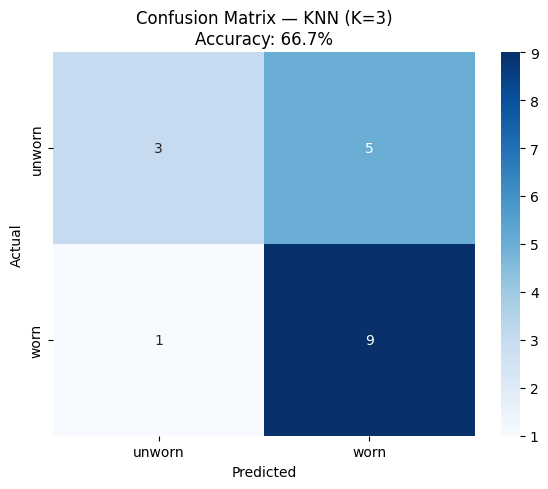


Final Report:
              precision    recall  f1-score   support

      unworn       0.75      0.38      0.50         8
        worn       0.64      0.90      0.75        10

    accuracy                           0.67        18
   macro avg       0.70      0.64      0.62        18
weighted avg       0.69      0.67      0.64        18


✅ Model saved as tool_wear_model.pkl


In [7]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Find best K for KNN
print("Finding best K value for KNN...")
print("-"*30)

best_k_acc = 0
best_k = 1

for k in range(1, 8):
    knn = Pipeline([('scaler', StandardScaler()),
                    ('knn', KNeighborsClassifier(n_neighbors=k))])
    loo = LeaveOneOut()
    preds, trues = [], []

    for train_idx, test_idx in loo.split(X_top):
        X_train, X_test = X_top.iloc[train_idx], X_top.iloc[test_idx]
        y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
        knn.fit(X_train, y_train)
        preds.append(knn.predict(X_test)[0])
        trues.append(y_test[0])

    acc = accuracy_score(trues, preds)
    print(f"K={k}  →  Accuracy: {acc*100:.1f}%")

    if acc > best_k_acc:
        best_k_acc = acc
        best_k = k

print(f"\n✅ Best K = {best_k} with {best_k_acc*100:.1f}% accuracy")

# Step 2: Final model with best K — get predictions for confusion matrix
final_knn = Pipeline([('scaler', StandardScaler()),
                      ('knn', KNeighborsClassifier(n_neighbors=best_k))])
loo = LeaveOneOut()
final_preds, final_trues = [], []

for train_idx, test_idx in loo.split(X_top):
    X_train, X_test = X_top.iloc[train_idx], X_top.iloc[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    final_knn.fit(X_train, y_train)
    final_preds.append(final_knn.predict(X_test)[0])
    final_trues.append(y_test[0])

# Step 3: Confusion Matrix
cm = confusion_matrix(final_trues, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title(f'Confusion Matrix — KNN (K={best_k})\nAccuracy: {best_k_acc*100:.1f}%')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Step 4: Final classification report
print("\nFinal Report:")
print(classification_report(final_trues, final_preds,
      target_names=le.classes_))

# Step 5: Save the final model
import joblib
final_knn.fit(X_top, y_encoded)  # train on ALL data
joblib.dump(final_knn, 'tool_wear_model.pkl')
joblib.dump(top10_features, 'selected_features.pkl')
print("\n✅ Model saved as tool_wear_model.pkl")

In [8]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score
import joblib

# ── 1. Load train labels ──────────────────────
df_train = pd.read_csv('train.csv')

# ── 2. Active cutting stages ──────────────────
active_stages = ['Layer 1 Up', 'Layer 1 Down',
                 'Layer 2 Up', 'Layer 2 Down',
                 'Layer 3 Up', 'Layer 3 Down']

sensor_cols = [
    'X1_ActualVelocity', 'X1_ActualAcceleration', 'X1_OutputCurrent',
    'Y1_ActualVelocity', 'Y1_ActualAcceleration', 'Y1_OutputCurrent',
    'Z1_ActualVelocity', 'Z1_ActualAcceleration', 'Z1_OutputCurrent',
    'S1_ActualVelocity', 'S1_OutputCurrent', 'S1_SystemInertia'
]

# ── 3. Feature extraction ─────────────────────
all_features = []
for i in range(1, 19):
    df = pd.read_csv(f'experiment_{i:02d}.csv')
    df_active = df[df['Machining_Process'].isin(active_stages)]
    row = {'experiment': i}
    for col in sensor_cols:
        if col in df_active.columns:
            row[f'{col}_mean'] = df_active[col].mean()
            row[f'{col}_std']  = df_active[col].std()
            row[f'{col}_max']  = df_active[col].max()
            row[f'{col}_rms']  = np.sqrt(np.mean(df_active[col]**2))
    all_features.append(row)

df_features = pd.DataFrame(all_features)
df_train['experiment'] = df_train['No']
df_final = df_features.merge(df_train[['experiment','tool_condition']], on='experiment')

# ── 4. Prepare X, y ──────────────────────────
X = df_final.drop(columns=['experiment','tool_condition']).fillna(0)
le = LabelEncoder()
y_encoded = le.fit_transform(df_final['tool_condition'])

# ── 5. Top 10 features ────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y_encoded)
importances = pd.Series(rf.feature_importances_, index=X.columns)
top10_features = importances.sort_values(ascending=False).head(10).index.tolist()
X_top = X[top10_features]

# ── 6. Train final KNN model ──────────────────
final_knn = Pipeline([('scaler', StandardScaler()),
                      ('knn', KNeighborsClassifier(n_neighbors=3))])
final_knn.fit(X_top, y_encoded)

# ── 7. Save files ─────────────────────────────
joblib.dump(final_knn, 'tool_wear_model.pkl')
joblib.dump(top10_features, 'selected_features.pkl')
print("✅ tool_wear_model.pkl saved!")
print("✅ selected_features.pkl saved!")
print("📂 Now check the folder icon on the left sidebar")

✅ tool_wear_model.pkl saved!
✅ selected_features.pkl saved!
📂 Now check the folder icon on the left sidebar


In [9]:
from google.colab import files
files.download('tool_wear_model.pkl')
files.download('selected_features.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
import joblib

# Check what top10_features contains
print(top10_features)

# Re-save it
joblib.dump(top10_features, 'selected_features.pkl')
print("✅ Saved!")

# Now download
from google.colab import files
files.download('selected_features.pkl')

['Y1_ActualVelocity_mean', 'Y1_ActualAcceleration_std', 'S1_ActualVelocity_rms', 'Y1_ActualAcceleration_rms', 'X1_ActualAcceleration_rms', 'Z1_ActualAcceleration_max', 'Z1_ActualVelocity_mean', 'Z1_ActualVelocity_std', 'S1_ActualVelocity_mean', 'S1_ActualVelocity_std']
✅ Saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import joblib

# Check what top10_features contains
print(top10_features)

# Re-save it
joblib.dump(top10_features, 'selected_features.pkl')
print("✅ Saved!")

# Now download
from google.colab import files
files.download('selected_features.pkl')


['Y1_ActualVelocity_mean', 'Y1_ActualAcceleration_std', 'S1_ActualVelocity_rms', 'Y1_ActualAcceleration_rms', 'X1_ActualAcceleration_rms', 'Z1_ActualAcceleration_max', 'Z1_ActualVelocity_mean', 'Z1_ActualVelocity_std', 'S1_ActualVelocity_mean', 'S1_ActualVelocity_std']
✅ Saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
from google.colab import files
files.download('selected_features.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>